In [2]:
import numpy as np
import pandas as pd
import sys
import os 

os.chdir("C:/Users/bella/SERGIO")
print(os.getcwd())

from SERGIO.sergio import sergio 

C:\Users\bella\SERGIO


# Simulate Clean Data _ Steady-State Simulation

In [ ]:
sim = sergio(number_genes=1200, number_bins = 9, number_sc = 300, noise_params = 1, decays=0.8, sampling_state=15, noise_type='dpd')
sim.build_graph(input_file_taregts =r"C:\Users\bella\SERGIO\data_sets\De-noised_1200G_9T_300cPerT_6_DS3\Interaction_cID_6.txt", input_file_regs=r"C:\Users\bella\SERGIO\data_sets\De-noised_1200G_9T_300cPerT_6_DS3\Regs_cID_6.txt", shared_coop_state=2)
sim.simulate()
expr = sim.getExpressions()
expr_clean = np.concatenate(expr, axis = 1)
print(expr_clean)

Start simulating new level
There are 2 genes to simulate in this layer
Done with current level
Start simulating new level
There are 3 genes to simulate in this layer
Done with current level
Start simulating new level
There are 5 genes to simulate in this layer
Done with current level
Start simulating new level
There are 9 genes to simulate in this layer
Done with current level
Start simulating new level
There are 26 genes to simulate in this layer
Done with current level
Start simulating new level
There are 82 genes to simulate in this layer


KeyboardInterrupt: 

# Add Technical Noise _ Steady-State Simulations

C:\Users\bella\SERGIO
Input shape: (2700, 1200)
Output shape: (1200, 2700)
     0  1  2  3  4   5  6  7    8  9  ...  2690  2691  2692  2693  2694  2695  \
0   23  0  0  0  0   0  0  0    0  0  ...     0     0     0     0     0    23   
1  112  0  0  0  0   0  0  0  112  0  ...     0     0     0     0     0     0   
2    0  0  0  0  0   0  0  0    0  0  ...     0     0     0     0     0    74   
3    0  0  0  0  0  49  0  0    0  0  ...     0     0    49     0     0     0   
4    0  0  0  0  0   0  0  0    0  0  ...     0     0     0     0     0     0   

   2696  2697  2698  2699  
0    23     0    23     0  
1     0     0     0     0  
2     0     0     0     0  
3    49     0     0     0  
4     0     0     0     0  

[5 rows x 2700 columns]


<Axes: >

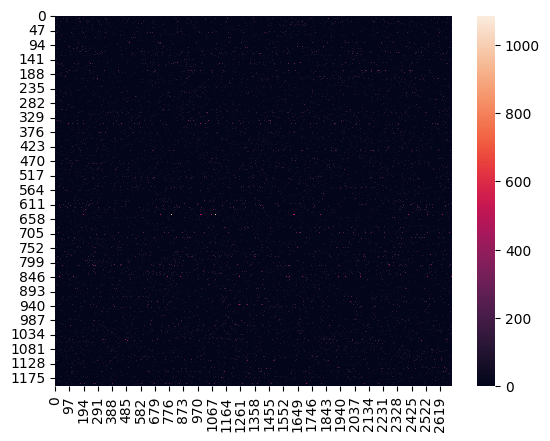

In [53]:
import pandas as pd
import numpy as np
from SERGIO.sergio import sergio
import seaborn as sns
import os
cwd = os.getcwd()
print(cwd)

# =========================
# LOAD CLEAN DATA
# =========================

df = pd.read_csv(
    r"C:\Users\bella\SERGIO\data_sets\De-noised_1200G_9T_300cPerT_6_DS3\simulated_noNoise_0.csv",
    index_col=0
)

gene_names = df.columns
cell_names = df.index

expr_clean = df.to_numpy().T  # (genes, cells)

print("Input shape:", expr_clean.shape)

# =========================
# SIGNAL PRESERVATION STEP
# =========================

# improve dynamic range and stabilise weak structure
expr_clean = np.log1p(expr_clean)
expr_clean = expr_clean * 2000

# ==========================================
# INITIALISE SERGIO (NOISE MODEL ONLY)
# ==========================================

sim = sergio(
    number_genes=expr_clean.shape[0],
    number_bins=1,
    number_sc=expr_clean.shape[1],
    noise_params=1,
    decays=0.8,
    sampling_state=15,
    noise_type='dpd'
)

# =========================
# FORMAT FOR SERGIO
# =========================

expr = [expr_clean]

# =================
# OUTLIERS (REDUCED)
# =================

expr_O = sim.outlier_effect(
    expr,
    outlier_prob=0.001,   # reduced from 0.01
    mean=0.8,
    scale=1
)

# =======================
# LIBRARY SIZE EFFECT
# =======================

libFactor, expr_O_L = sim.lib_size_effect(
    expr_O,
    mean=6,              # reduced
    scale=0.3            # reduced variance
)

# =================
# DROPOUTS (LESS AGGRESSIVE)
# =================

binary_ind = sim.dropout_indicator(
    expr_O_L,
    shape=1,             # reduced from 2
    percentile=15        # key improvement
)

expr_O_L_D = np.multiply(binary_ind, expr_O_L)

# =====================
# STABILISE BEFORE UMI
# =====================

expr_O_L_D = np.clip(expr_O_L_D, 0, np.percentile(expr_O_L_D, 99))

# =====================
# CONVERT TO UMI COUNTS
# =====================

count_matrix = sim.convert_to_UMIcounts(expr_O_L_D)
count_matrix = np.concatenate(count_matrix).T

# =========================
# RESCALE TO REALISTIC DEPTH
# =========================

# simulate library sizes similar to metatranscriptomics
library_sizes = np.random.lognormal(mean=9.5, sigma=0.5, size=count_matrix.shape[0])

# normalize then rescale
count_matrix = count_matrix / np.sum(count_matrix, axis=1, keepdims=True)
count_matrix = count_matrix * library_sizes[:, None]

# convert to integer counts
count_matrix = np.round(count_matrix).astype(int)

# =================
# SAVE OUTPUT
# =================

df_noisy = pd.DataFrame(
    count_matrix,
    index=cell_names,
    columns=gene_names
)

df_noisy.to_csv("noisy_expression_optimised.csv")

print("Output shape:", df_noisy.shape)
print(df_noisy.head())

# =================
# VISUAL CHECK
# =================

sns.heatmap(df_noisy)